# Bayesian Network Visualization for Vulnerability Analysis

This notebook visualizes the results of Bayesian Network analysis on code vulnerability fixes. The analysis examines relationships between different types of code changes and their impact on vulnerability status.

In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Try to import networkx, fallback to basic visualization
try:
    import networkx as nx
    HAS_NETWORKX = True
except ImportError:
    HAS_NETWORKX = False
    print("NetworkX not available, using basic network visualization")

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# Import project utilities
from megavul_diff_analysis.utils.config_utils import find_project_root

## Load Bayesian Network Data

Load the Conditional Probability Distributions (CPDs) and network structure from the BN1 analysis results.

In [10]:
# Find project root and data paths
project_root = find_project_root()
results_dir = project_root / 'data' / 'results' / 'bn1' / 'bn1_hillclimb_mi50_tabu10_hcs'

# Load CPDs (Conditional Probability Distributions)
cpds_path = results_dir / 'bn1_hillclimb_mi50_tabu10_hcs_cpds.json'
with open(cpds_path, 'r') as f:
    cpds_data = json.load(f)

# Load network edges
edges_path = results_dir / 'bn1_hillclimb_mi50_tabu10_hcs_edges.json'
with open(edges_path, 'r') as f:
    edges_data = json.load(f)

print(f"Loaded {len(cpds_data)} CPDs and {len(edges_data)} edges")
print(f"Variables in the network: {[cpd['variable'] for cpd in cpds_data]}")

Loaded 51 CPDs and 69 edges
Variables in the network: ['delete-node_If_Block', 'delete-node_LocalVariable_Block', 'delete-node_VariableRead_Invocation', 'move-tree_BinaryOperator_LocalVariable', 'delete-node_Assignment_Block', 'move-tree_VariableRead_BinaryOperator', 'insert-node_If_Block', 'is_vul', 'insert-node_Invocation_Block', 'delete-node_Invocation_LocalVariable', 'delete-node_Parameter_Method', 'insert-node_Invocation_LocalVariable', 'insert-node_Parameter_Method', 'insert-node_FieldRead_ConstructorCall', 'delete-node_BinaryOperator_If', 'delete-node_Invocation_Invocation', 'insert-node_Annotation_Method', 'delete-node_Block_If', 'insert-node_Invocation_Invocation', 'insert-node_BinaryOperator_If', 'delete-node_Invocation_ConstructorCall', 'insert-node_Invocation_ConstructorCall', 'delete-node_FieldRead_ConstructorCall', 'insert-node_Block_If', 'insert-node_Annotation_Parameter', 'delete-node_Annotation_Parameter', 'delete-node_TypeAccess_Invocation', 'insert-node_TypeAccess_In

## Network Structure Visualization

Visualize the Bayesian Network structure showing relationships between code change types and vulnerability.

/tmp/ipykernel_5553/1694727559.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


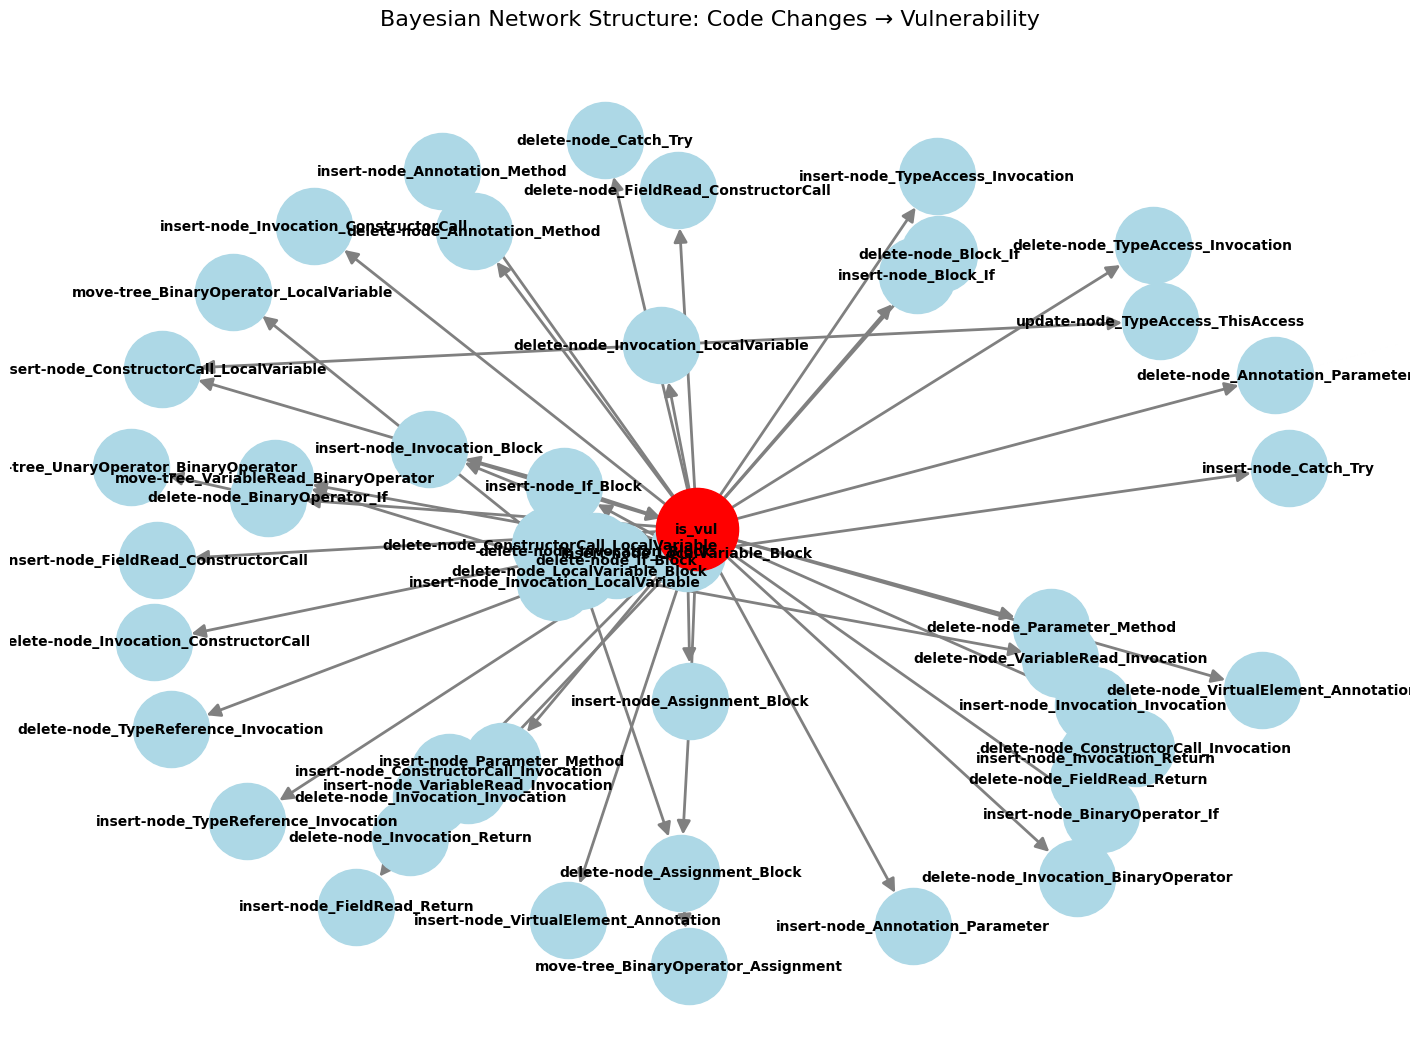

Number of nodes: 51
Number of edges: 69
Network density: 0.027


In [11]:
# Create network graph
if HAS_NETWORKX:
    G = nx.DiGraph()

    # Add nodes
    variables = [cpd['variable'] for cpd in cpds_data]
    G.add_nodes_from(variables)

    # Add edges
    for edge in edges_data:
        G.add_edge(edge['source'], edge['target'])

    # Create positions for nodes
    pos = nx.spring_layout(G, seed=42)

    # Draw the network
    plt.figure(figsize=(14, 10))
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            node_size=3000, font_size=10, font_weight='bold',
            arrows=True, arrowsize=20, edge_color='gray', width=2)

    # Highlight the vulnerability node
    vulnerability_nodes = [node for node in G.nodes() if 'is_vul' in node]
    nx.draw_networkx_nodes(G, pos, nodelist=vulnerability_nodes,
                          node_color='red', node_size=3500)

    plt.title('Bayesian Network Structure: Code Changes → Vulnerability', fontsize=16, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print network statistics
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    if HAS_NETWORKX:
        print(f"Network density: {nx.density(G):.3f}")
else:
    # Fallback: Create a simple adjacency matrix visualization
    variables = list(set([cpd['variable'] for cpd in cpds_data] +
                        [edge['source'] for edge in edges_data] +
                        [edge['target'] for edge in edges_data]))

    # Create adjacency matrix
    adj_matrix = pd.DataFrame(0, index=variables, columns=variables)
    for edge in edges_data:
        if edge['source'] in adj_matrix.index and edge['target'] in adj_matrix.columns:
            adj_matrix.loc[edge['source'], edge['target']] = 1

    plt.figure(figsize=(12, 10))
    sns.heatmap(adj_matrix, annot=True, cmap='Blues', cbar=False, square=True)
    plt.title('Bayesian Network Adjacency Matrix: Code Changes → Vulnerability', fontsize=14)
    plt.xlabel('Target Node')
    plt.ylabel('Source Node')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"Number of nodes: {len(variables)}")
    print(f"Number of edges: {len(edges_data)}")

## Conditional Probability Distributions

Visualize the probability distributions for each variable in the network, showing how different code changes affect vulnerability likelihood.

In [ ]:
# Function to visualize CPD tables
def plot_cpd_heatmap(cpd_data, ax=None):
    """Plot a heatmap for a conditional probability distribution"""
    variable = cpd_data['variable']
    table = cpd_data['table']

    if not table:
        return

    # Convert table to DataFrame
    df = pd.DataFrame(table)

    # Extract probability columns (ending with =0 or =1)
    prob_cols = [col for col in df.columns if '=' in col and col.split('=')[1] in ['0', '1']]
    parent_cols = [col for col in df.columns if col not in prob_cols]

    if not prob_cols:
        return

    # Create a more readable format
    plot_data = []
    for _, row in df.iterrows():
        parent_values = {col: row[col] for col in parent_cols}
        for prob_col in prob_cols:
            state = prob_col.split('=')[1]
            prob = row[prob_col]
            plot_row = parent_values.copy()
            plot_row['State'] = state
            plot_row['Probability'] = prob
            plot_data.append(plot_row)

    plot_df = pd.DataFrame(plot_data)

    # Create pivot table for heatmap
    if len(parent_cols) == 1:
        pivot = plot_df.pivot(index=parent_cols[0], columns='State', values='Probability')
    elif len(parent_cols) == 2:
        pivot = plot_df.pivot(index=parent_cols[0], columns=[parent_cols[1], 'State'], values='Probability')
    else:
        # For more complex cases, just show bar chart
        return plot_cpd_bar(cpd_data, ax)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', ax=ax, cbar_kws={'label': 'Probability'})
    ax.set_title(f'CPD for {variable}', fontsize=12)
    ax.set_ylabel(parent_cols[0] if len(parent_cols) >= 1 else 'Parent State')

    return ax

def plot_cpd_bar(cpd_data, ax=None):
    """Plot a bar chart for CPD when heatmap is not suitable"""
    variable = cpd_data['variable']
    table = cpd_data['table']

    if not table:
        return

    df = pd.DataFrame(table)
    prob_cols = [col for col in df.columns if '=' in col and col.split('=')[1] in ['0', '1']]

    if not prob_cols:
        return

    # Melt the dataframe for easier plotting
    melted = df.melt(id_vars=[col for col in df.columns if col not in prob_cols],
                     value_vars=prob_cols, var_name='State_Prob', value_name='Probability')

    melted['State'] = melted['State_Prob'].apply(lambda x: x.split('=')[1])

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    if len(melted) <= 10:  # Simple case
        sns.barplot(data=melted, x='State', y='Probability', ax=ax)
    else:
        # Group by state for complex cases
        state_means = melted.groupby('State')['Probability'].mean()
        state_means.plot(kind='bar', ax=ax)

    ax.set_title(f'CPD for {variable}', fontsize=12)
    ax.set_ylabel('Probability')
    ax.set_xlabel('State')

    return ax

# Plot CPDs for variables leading to is_vul
# Get ancestors of is_vul (variables that influence it)
if HAS_NETWORKX:
    ancestors = list(nx.ancestors(G, 'is_vul'))
    # Get topological order of ancestors (grandparents before parents)
    topo_order = list(nx.topological_sort(G))
    # Only keep ancestors, in topo order
    ordered_ancestors = [v for v in topo_order if v in ancestors]
else:
    # Fallback: manually find ancestors by traversing edges backwards
    ancestors = set()
    to_check = ['is_vul']
    visited = set()
    while to_check:
        current = to_check.pop()
        if current in visited:
            continue
        visited.add(current)
        for edge in edges_data:
            if edge['target'] == current:
                ancestors.add(edge['source'])
                to_check.append(edge['source'])
    # Fallback: try to order by distance from is_vul (BFS)
    def ancestor_distance(var):
        # BFS from var to is_vul
        queue = [(var, 0)]
        visited_bfs = set()
        while queue:
            node, dist = queue.pop(0)
            if node == 'is_vul':
                return dist
            for edge in edges_data:
                if edge['source'] == node and edge['target'] not in visited_bfs:
                    queue.append((edge['target'], dist+1))
                    visited_bfs.add(edge['target'])
        return 9999
    ordered_ancestors = sorted(list(ancestors), key=ancestor_distance, reverse=True)

print(f"Variables leading to is_vul (ordered): {ordered_ancestors}")

# Select CPDs for ancestors in order
selected_cpds = [cpd for name in ordered_ancestors for cpd in cpds_data if cpd['variable'] == name]
print(f"Selected CPDs for ancestors: {[cpd['variable'] for cpd in selected_cpds]}")

# Always plot in a single row
n = len(selected_cpds)
if n == 0:
    print("No variables leading to is_vul found.")
else:
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    # Make axes always iterable
    if n == 1:
        axes = [axes]

    for i, cpd in enumerate(selected_cpds):
        print(f"Plotting CPD for {cpd['variable']}")
        try:
            plot_cpd_heatmap(cpd, axes[i])
        except Exception as e:
            print(f"Heatmap failed for {cpd['variable']}: {e}")
            plot_cpd_bar(cpd, axes[i])

    plt.tight_layout()
    plt.show()


## Vulnerability Impact Analysis

Analyze which code changes have the strongest influence on vulnerability likelihood.

Variables directly influencing vulnerability:
Parents: ['insert-node_Assignment_Block', 'insert-node_If_Block', 'insert-node_Invocation_Block']


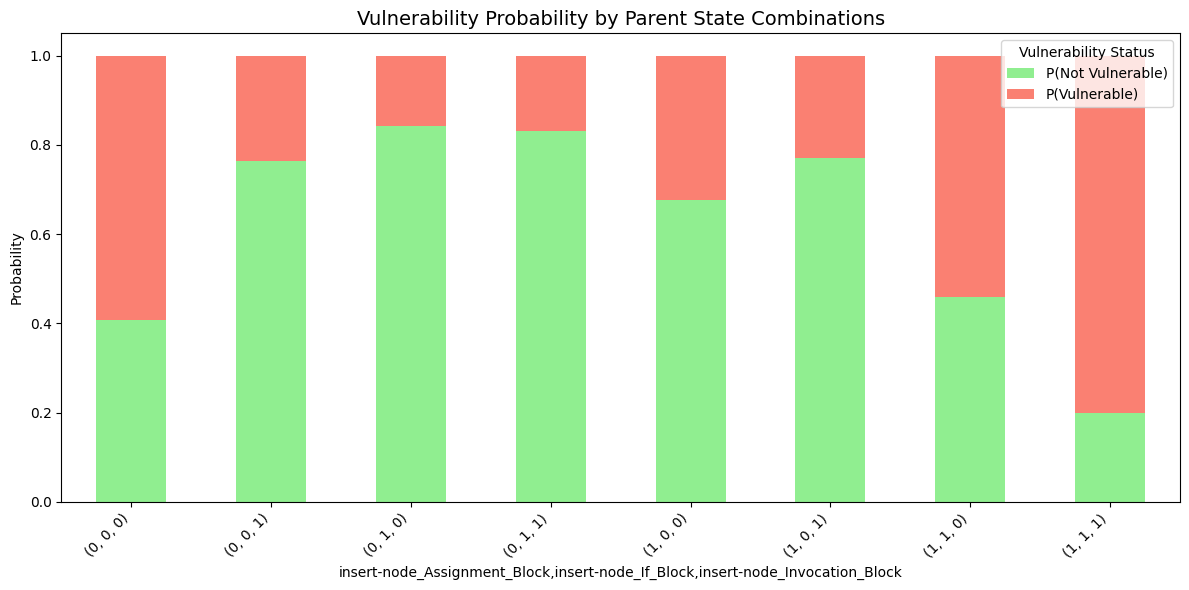


Network Analysis:
Variables with paths to vulnerability: 45
Variables that vulnerability depends on: 4

Node degrees (in, out):
  delete-node_Annotation_Method: (1, 1)
  delete-node_Annotation_Parameter: (1, 0)
  delete-node_Assignment_Block: (2, 1)
  delete-node_BinaryOperator_If: (2, 1)
  delete-node_Block_If: (1, 1)
  delete-node_Catch_Try: (1, 0)
  delete-node_ConstructorCall_Invocation: (1, 1)
  delete-node_ConstructorCall_LocalVariable: (1, 1)
  delete-node_FieldRead_ConstructorCall: (1, 0)
  delete-node_FieldRead_Return: (1, 0)
  delete-node_If_Block: (2, 1)
  delete-node_Invocation_BinaryOperator: (1, 0)
  delete-node_Invocation_Block: (2, 2)
  delete-node_Invocation_ConstructorCall: (1, 0)
  delete-node_Invocation_Invocation: (2, 2)
  delete-node_Invocation_LocalVariable: (1, 2)
  delete-node_Invocation_Return: (2, 1)
  delete-node_LocalVariable_Block: (3, 4)
  delete-node_Parameter_Method: (1, 1)
  delete-node_TypeAccess_Invocation: (1, 0)
  delete-node_TypeReference_Invocat

In [13]:
# Find variables that directly influence vulnerability
vul_cpd = None
for cpd in cpds_data:
    if cpd['variable'] == 'is_vul':
        vul_cpd = cpd
        break

if vul_cpd:
    print("Variables directly influencing vulnerability:")
    print(f"Parents: {vul_cpd['parents']}")

    # Extract probabilities
    table = vul_cpd['table']
    df_vul = pd.DataFrame(table)

    # Calculate vulnerability probabilities for different parent combinations
    vul_probs = []
    for _, row in df_vul.iterrows():
        parent_states = {k: v for k, v in row.items() if k != 'is_vul=0' and k != 'is_vul=1'}
        p_vul_0 = row.get('is_vul=0', 0)
        p_vul_1 = row.get('is_vul=1', 0)

        vul_probs.append({
            **parent_states,
            'P(Not Vulnerable)': p_vul_0,
            'P(Vulnerable)': p_vul_1
        })

    vul_df = pd.DataFrame(vul_probs)

    # Visualize vulnerability probabilities
    if len(vul_df) <= 10:
        vul_df.set_index(list(parent_states.keys())).plot(
            kind='bar', stacked=True, figsize=(12, 6),
            color=['lightgreen', 'salmon']
        )
        plt.title('Vulnerability Probability by Parent State Combinations', fontsize=14)
        plt.ylabel('Probability')
        plt.legend(title='Vulnerability Status')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        # Summary statistics
        print(f"Average P(Vulnerable): {vul_df['P(Vulnerable)'].mean():.3f}")
        print(f"Max P(Vulnerable): {vul_df['P(Vulnerable)'].max():.3f}")
        print(f"Min P(Vulnerable): {vul_df['P(Vulnerable)'].min():.3f}")

# Analyze indirect influences through the network
print("\nNetwork Analysis:")
if HAS_NETWORKX:
    print(f"Variables with paths to vulnerability: {len(list(nx.descendants(G, 'is_vul')))}")
    print(f"Variables that vulnerability depends on: {len(list(nx.ancestors(G, 'is_vul')))}")

    # Calculate node degrees
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())

    print(f"\nNode degrees (in, out):")
    for node in sorted(G.nodes()):
        print(f"  {node}: ({in_degrees.get(node, 0)}, {out_degrees.get(node, 0)})")
else:
    # Simple analysis without networkx
    sources = set(edge['source'] for edge in edges_data)
    targets = set(edge['target'] for edge in edges_data)
    all_nodes = sources | targets

    print(f"Total variables: {len(all_nodes)}")
    print(f"Variables with outgoing connections: {len(sources)}")
    print(f"Variables with incoming connections: {len(targets)}")

    # Count connections
    in_degree = {}
    out_degree = {}
    for node in all_nodes:
        in_degree[node] = sum(1 for edge in edges_data if edge['target'] == node)
        out_degree[node] = sum(1 for edge in edges_data if edge['source'] == node)

    print(f"\nNode degrees (in, out):")
    for node in sorted(all_nodes):
        print(f"  {node}: ({in_degree.get(node, 0)}, {out_degree.get(node, 0)})")

## Summary

This notebook provides visualizations of the Bayesian Network analysis results for vulnerability fixes in code changes. Key insights:

1. **Network Structure**: Shows the relationships between different types of code modifications and vulnerability status
2. **Probability Distributions**: Visualizes how different combinations of code changes affect the likelihood of vulnerabilities
3. **Vulnerability Impact**: Identifies which code changes have the strongest influence on security

The analysis helps understand how specific code modification patterns correlate with vulnerability introduction or fixes.